# Macro Stress Testing Engine for Credit Portfolio Valuation Impact

**Purpose:** Link US macro risk factors to consumer credit-card charge-off rates, validate an explainable ARDL / regression model against naive and ML challengers, and quantify **expected-loss / fair-value impact** under historical and hypothetical stress.

## 1. Problem & decision context

**Business question:** If macro conditions deteriorate (GFC-like, COVID-like, or a designed adverse multi-factor shock), how much could credit-card charge-off rates — and therefore expected loss / carrying-value impact on an illustrative book — move?

**Answer engine:** lagged macros → charge-off rate → stress scenarios → $ EL on an assumed EAD. Diagnostics exist to make that answer defensible.


In [1]:
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
currentPath = os.getcwd()
dataPath = os.path.join(currentPath, "data")

# Make sure the data directory exists
if not os.path.exists(dataPath):
    os.makedirs(dataPath)

## 2. Data lineage & load

In [3]:
FRED_CSV = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

# Outcome + macro factors used by the stress engine
SERIES = {
    "CORCCACBS": "charge_off_rate",  # Credit-card charge-off rate, % (quarterly)
    "UNRATE": "unemployment",  # Unemployment rate, % (monthly)
    "GDPC1": "real_gdp",  # Real GDP, bil. chained 2017$ (quarterly)
    "FEDFUNDS": "fed_funds",  # Effective fed funds rate, % (monthly)
    "BAA10Y": "credit_spread",  # Baa–10Y Treasury spread, % (daily)
    "VIXCLS": "vix",  # CBOE VIX (daily)
}

In [4]:
def fetch_series(series_id: str) -> pd.Series:
    url = FRED_CSV.format(series_id=series_id)
    df = pd.read_csv(url)
    s = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    s.index = pd.to_datetime(df.iloc[:, 0])
    s.name = SERIES[series_id]
    return s.dropna().sort_index()

raw = {sid: fetch_series(sid) for sid in SERIES}

summary = pd.DataFrame([
    {
        "fred_id": sid,
        "name": s.name,
        "start": s.index.min().date(),
        "end": s.index.max().date(),
        "n": len(s),
        "last": round(float(s.iloc[-1]), 2),
    }
    for sid, s in raw.items()
]).set_index("fred_id")

display(summary)

,name,start,end,n,last
fred_id,,,,,
CORCCACBS,charge_off_rate,1985-01-01,2026-04-01,166,3.82
UNRATE,unemployment,1948-01-01,2026-08-01,943,4.10
GDPC1,real_gdp,1947-01-01,2026-04-01,318,24269.61
FEDFUNDS,fed_funds,1954-07-01,2026-08-01,866,3.63
BAA10Y,credit_spread,1986-01-02,2026-09-24,10183,1.39
VIXCLS,vix,1990-01-02,2026-09-22,9279,14.21


**Interpretation**

Pulled public FRED series.

Outcome **Y** = `CORCCACBS` (credit-card charge-off rate %).

Drivers **X**:

| Series | Why it belongs |
|--------|----------------|
| Unemployment (`UNRATE`) | Jobs → ability to pay |
| Real GDP (`GDPC1` → later YoY %) | Growth / recession channel |
| Fed funds (`FEDFUNDS`) | Policy rate / servicing cost |
| Credit spread (`BAA10Y`) | Market risk premium / credit stress |
| VIX (`VIXCLS`) | Fear / crisis timing |

Different `n` and start dates are **expected** (daily VIX vs monthly UE vs quarterly charge-offs)

Last values look economically plausible (e.g. unemployment ~4%, charge-off ~3.8%, not absurd scales).

## 3. EDA

Align to quarter-end, convert GDP to YoY %, then plot Y and Xs with GFC / COVID windows shaded.

In [5]:
# Transform the data to quarterly frequency
frames = {}
for sid, s in raw.items():
    name = SERIES[sid]
    frames[name] = s.resample("QE").last()

panel = pd.DataFrame(frames).sort_index()
panel["gdp_yoy"] = panel["real_gdp"].pct_change(4) * 100.0
panel = panel.drop(columns=["real_gdp"]).dropna(how="any")
panel.describe().round(2)

,charge_off_rate,unemployment,fed_funds,credit_spread,vix,gdp_yoy
count,146.00,146.00,146.00,146.00,146.00,146.00
mean,4.42,5.63,2.88,2.30,19.52,2.50
std,1.62,1.67,2.33,0.73,7.52,1.98
min,1.63,3.50,0.07,1.30,9.51,-7.40
25%,3.48,4.32,0.27,1.76,13.90,1.80
50%,4.14,5.20,2.78,2.18,17.46,2.60
75%,4.90,6.50,5.24,2.71,23.23,3.42
max,10.54,11.00,8.29,5.82,53.54,12.39


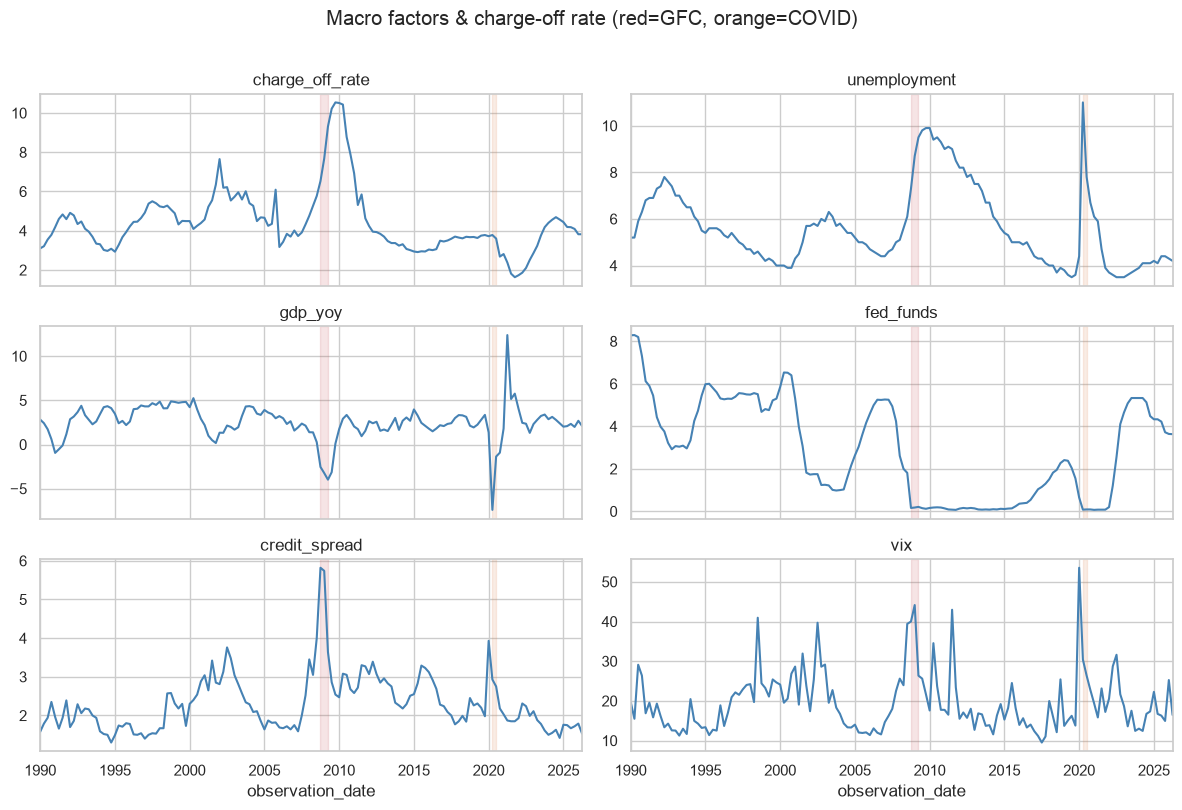

In [6]:
FACTOR_COLS = ["unemployment", "gdp_yoy", "fed_funds", "credit_spread", "vix"]
TARGET_COL = "charge_off_rate"
cols = [TARGET_COL] + FACTOR_COLS

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for ax, c in zip(axes.ravel(), cols):
    panel[c].plot(ax=ax, color="steelblue")
    ax.set_title(c)
    ax.axvspan(pd.Timestamp("2008-10-01"), pd.Timestamp("2009-06-30"), color="C3", alpha=0.15)
    ax.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2020-09-30"), color="C1", alpha=0.15)
fig.suptitle("Macro factors & charge-off rate (red=GFC, orange=COVID)", y=1.01)
fig.tight_layout()

**Interpretation**

Most factors and charge-offs move sharply in the shaded crisis windows:

- **GFC (~2008Q4–2009Q2):** unemployment, spreads, VIX rise; GDP YoY collapses; charge-offs climb.
- **COVID (~2020Q2–Q3, not 2021):** unemployment and VIX spike; GDP YoY plunges.

Losses often **lag** macros — charge-offs stay elevated after the first shock quarter. That visual pattern is why we use **lag-1** features and later multi-quarter stress paths. These same shaded windows become the historical stress definitions.

## 4. Hypotheses

- **H1:** Higher lagged unemployment, credit spreads, and VIX raise charge-off rates; stronger GDP growth lowers them.
- **H2:** An ARDL (own lag + lagged macros) beats naive-last and naive-mean on out-of-time MAE/RMSE.
- **H3:** Historical crisis factor paths and multi-factor adverse shocks produce material ΔEL vs the latest actual on a $1bn illustrative EAD.

## 5. Pre-modeling diagnostics — ADF + KPSS

ADF and KPSS have **opposite nulls**. We use both so we do not fake certainty from a single test.

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss

rows = []
for col in panel.columns:
    s = panel[col]
    adf_p = adfuller(s, autolag="AIC")[1]

    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = np.nan

    rows.append({
        "series": col,
        "adf_pvalue": adf_p,
        "kpss_pvalue": kpss_p,
        "adf_stationary": adf_p < 0.05,
        "kpss_stationary": (kpss_p >= 0.05) if pd.notna(kpss_p) else None
    })

stat = pd.DataFrame(rows).set_index("series")
display(stat.round(4))

,adf_pvalue,kpss_pvalue,adf_stationary,kpss_stationary
series,,,,
charge_off_rate,0.0019,0.1000,True,True
unemployment,0.1234,0.1000,False,True
fed_funds,0.0182,0.0114,True,False
credit_spread,0.0032,0.1000,True,True
vix,0.0000,0.1000,True,True
gdp_yoy,0.0456,0.1000,True,True


**Interpretation**

| Series | Reading |
|--------|--------|
| charge_off_rate, credit_spread, vix, gdp_yoy | ADF rejects unit root and KPSS does not reject stationarity → OK to use in levels |
| unemployment | ADF p≈0.12 (does **not** reject unit root); KPSS still consistent with stationarity → **borderline / ambiguous** |
| fed_funds | ADF suggests stationary; KPSS p≈0.01 rejects stationarity → **tests disagree** |

Common in macro data. We **document** the borderline cases and proceed with a levels ARDL (standard in illustrative credit-stress work), rather than pretending every series is cleanly stationary. If this were a production MRM model, differencing / richer dynamics would be the next challenge.

## 6. Lagged modeling frame

In [8]:
df = panel.copy()
df[f"{TARGET_COL}_L1"] = df[TARGET_COL].shift(1)

for c in FACTOR_COLS:
    df[f"{c}_L1"] = df[c].shift(1)

feature_cols = [f"{TARGET_COL}_L1"] + [f"{c}_L1" for c in FACTOR_COLS]
model_df = df.dropna(subset=feature_cols + [TARGET_COL])

display(model_df.head())

,charge_off_rate,unemployment,fed_funds,credit_spread,vix,gdp_yoy,charge_off_rate_L1,unemployment_L1,gdp_yoy_L1,fed_funds_L1,credit_spread_L1,vix_L1
observation_date,,,,,,,,,,,,
1990-06-30,3.21,5.2,8.29,1.79,15.50,2.412705,3.10,5.2,2.821007,8.28,1.58,19.73
1990-09-30,3.55,5.9,8.20,1.94,29.11,1.727362,3.21,5.2,2.412705,8.29,1.79,15.50
1990-12-31,3.79,6.3,7.31,2.35,26.38,0.603063,3.55,5.9,1.727362,8.20,1.94,29.11
1991-03-31,4.18,6.8,6.12,1.96,16.88,-0.950197,3.79,6.3,0.603063,7.31,2.35,26.38
1991-06-30,4.60,6.9,5.90,1.66,19.55,-0.538931,4.18,6.8,-0.950197,6.12,1.96,16.88


**Why lag-1**

1. **Delay:** Credit losses react after macros move (collections, policy, recognition lag).
2. **No same-quarter circularity:** Using contemporaneous macros can look like “prediction” when it is only correlation in the same quarter.
3. **Persistence:** `charge_off_rate_L1` captures sticky charge-offs — last quarter’s loss rate is strong information for this quarter.

`_L1` means “known at t−1.” Y stays at time t. The first row drops after `shift`.

## 7. Primary model — ARDL OLS & out-of-time split

Train ≤ 2018-12-31; test is the later window.

The regression model is defined as

$\text{CO}_t = \alpha + \beta \text{CO}_{t-1} + \gamma_1 \text{UE}_{t-1} + \gamma_2 \text{GDP}_{t-1} + \gamma_3 r_{t-1} + \gamma_4 \text{Spread}_{t-1} + \gamma_5 \text{VIX}_{t-1} + \varepsilon_t$.

In [9]:
cutoff = "2018-12-31"

train = model_df.loc[:cutoff].copy()
test = model_df.loc[cutoff:].iloc[1:].copy()

y_train = train[TARGET_COL]
X_train = sm.add_constant(train[feature_cols])

model = sm.OLS(y_train, X_train).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        charge_off_rate   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     193.3
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.27e-55
Time:                        14:05:04   Log-Likelihood:                -79.151
No. Observations:                 115   AIC:                             172.3
Df Residuals:                     108   BIC:                             191.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6593      0

**Interpretation — OLS**

The ARDL explains charge-off rates well in-sample (R² ≈ 0.92), but that fit is driven mainly by the lagged charge-off itself. **Out-of-time accuracy vs naive baselines is the real success check — not R².**

**Coefficient sign-check**

- **const (0.66, p=0.15):** Intercept is positive but imprecise; not economically central.
- **charge_off_rate_L1 (0.91, p<0.001):** Strong positive persistence. Charge-offs move slowly; one-step stress understates multi-quarter crises, so path recursion is needed later (Step 10).
- **unemployment_L1 (−0.07, p=0.09):** Wrong sign vs intuition and not significant at 5%. Do not over-claim an unemployment channel from this OLS alone.
- **gdp_yoy_L1 (−0.16, p<0.001):** Clear negative link: stronger real growth → lower next-quarter charge-offs. Main macro driver in this fit.
- **fed_funds_L1 (0.06, p=0.048):** Mild positive link: higher policy rates → slightly higher charge-offs. Borderline significant.
- **credit_spread_L1 (0.17, p=0.21):** Right sign (wider spreads → higher CO) but noisy / not significant.
- **vix_L1 (≈0, p≈1):** No meaningful linear effect after other factors.

**Diagnostics note:** Residuals show non-normality (fat tails / outliers), common around crises. Condition number ≈ 223 → check VIF next. High in-sample R² with a large own lag is expected and does not by itself validate the stress engine.

## 8. Post-modeling diagnostics — VIF, residuals, Ljung-Box

VIF asks whether predictors are collinear with **each other** (not with Y). Ljung-Box asks whether residuals still have leftover time pattern.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(train[feature_cols])
vif_rows = []

for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    vif_rows.append({"feature": col, "vif": variance_inflation_factor(X_vif.values, i)})

pd.DataFrame(vif_rows).sort_values("vif", ascending=False).round(2)

,feature,vif
4,credit_spread_L1,4.69
5,vix_L1,3.05
3,fed_funds_L1,2.52
1,unemployment_L1,2.06
0,charge_off_rate_L1,1.99
2,gdp_yoy_L1,1.89


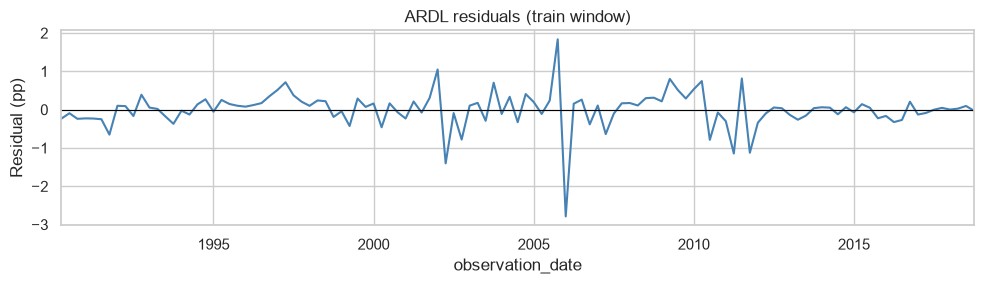

In [11]:
# Residual time series — visual check for leftover structure / crisis clumps
fig, ax = plt.subplots(figsize=(10, 3))
model.resid.plot(ax=ax, color="steelblue")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("ARDL residuals (train window)")
ax.set_ylabel("Residual (pp)")
fig.tight_layout()
plt.show()

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(model.resid, lags=[4, 8], return_df=True)
print(lb)

     lb_stat  lb_pvalue
4  11.130998   0.025131
8  13.291307   0.102212


**Interpretation — VIF, residuals, Ljung-Box**

**VIF (compare each X to other X’s — not to Y):**

| Feature | VIF | Reading |
|---------|-----|--------|
| credit_spread_L1 | ≈4.69 | Highest, still **below 5** |
| vix_L1 | ≈3.05 | Mild overlap |
| fed_funds_L1 | ≈2.52 | Fine |
| unemployment_L1 | ≈2.06 | Fine |
| charge_off_rate_L1 | ≈1.99 | Fine |
| gdp_yoy_L1 | ≈1.89 | Fine |

All VIF &lt; 5 → no severe multicollinearity; coefficient stories are usable (with the honesty already noted on weak/wrong-sign macros).

**Residuals:** Roughly centered at 0. Crisis-period clumps / fat tails are common; linear ARDL may miss nonlinear stress.

**Ljung-Box on residuals:**

- Lag 4: p ≈ **0.025** → reject “no autocorrelation” at 5% → **mild leftover time pattern** (model incomplete in a dynamic sense).
- Lag 8: p ≈ **0.10** → weaker evidence at longer lag.

**Honest limitation (keep for Step 13):** richer lags / ECM could be next; do not hide the lag-4 result. Still proceed to Step 8 — OOT vs naive is the forecasting gate.

## 9. Naive benchmarks + ML challenger

On the **out-of-time (post-2018)** window, compare ARDL OLS to lazy baselines and a GBM challenger. MAE/RMSE are in charge-off **percentage points**.

- **naive-last:** tomorrow = last train charge-off
- **naive-mean:** tomorrow = train mean charge-off
- **GBM:** same lag features — predictive lift check only, **not** the governance model


,model,MAE,RMSE
0,ARDL_OLS_primary,0.3225,0.4691
1,GBM_challenger,0.4549,0.6241
2,naive_last,0.7300,0.9580
3,naive_mean,1.2851,1.5814


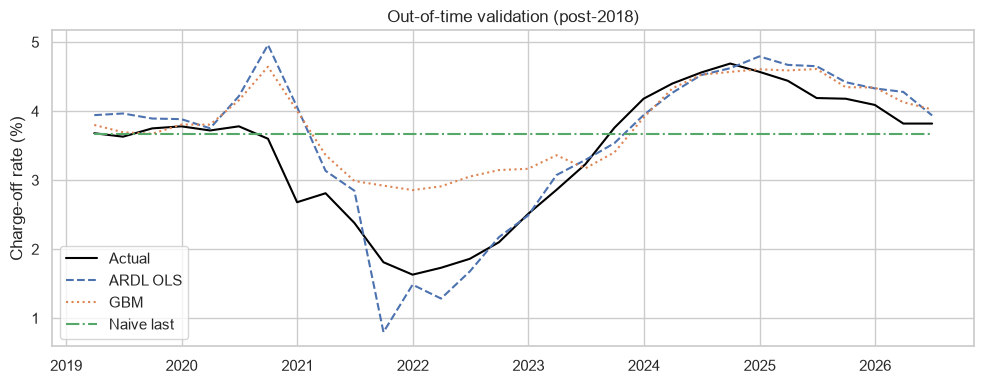

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mae_rmse(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }

y_test = test[TARGET_COL]
X_test = sm.add_constant(test[feature_cols], has_constant="add")
X_test = X_test.reindex(columns=model.model.exog_names, fill_value=0.0)

pred_ols = model.predict(X_test)
pred_naive_last = np.full(len(test), train[TARGET_COL].iloc[-1])
pred_naive_mean = np.full(len(test), train[TARGET_COL].mean())

gbm = GradientBoostingRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42
)
gbm.fit(train[feature_cols], train[TARGET_COL])
pred_gbm = gbm.predict(test[feature_cols])

oot = pd.DataFrame([
    {"model": "ARDL_OLS_primary", **mae_rmse(y_test, pred_ols)},
    {"model": "GBM_challenger", **mae_rmse(y_test, pred_gbm)},
    {"model": "naive_last", **mae_rmse(y_test, pred_naive_last)},
    {"model": "naive_mean", **mae_rmse(y_test, pred_naive_mean)},
])
display(oot.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test.index, y_test, label="Actual", color="black")
ax.plot(test.index, pred_ols, label="ARDL OLS", ls="--")
ax.plot(test.index, pred_gbm, label="GBM", ls=":")
ax.plot(test.index, pred_naive_last, label="Naive last", ls="-.")
ax.set_title("Out-of-time validation (post-2018)")
ax.set_ylabel("Charge-off rate (%)")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation**

Primary **ARDL OLS** has the lowest MAE (~0.32) and beats both naives (naive-last ~0.73, naive-mean ~1.29). GBM challenger (~0.46) also beats naive but loses to ARDL — so the explainable model is also the best forecast here.

That is enough to use ARDL as the **stress engine**. GBM stays a challenger only (shows we checked nonlinear lift). High in-sample R² alone would not have been enough — beating naive out-of-time is the real gate.


## 10. Independent replication (sklearn vs statsmodels)

Refit the same linear model with sklearn. If coefficients match, the OLS result is not a one-library accident (effective challenge).


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(train[feature_cols], train[TARGET_COL])
sm_coefs = model.params.drop("const")
sk_coefs = pd.Series(lr.coef_, index=feature_cols)
max_diff = float((sm_coefs - sk_coefs).abs().max())
print("max |Δcoef| =", max_diff)
print("PASS" if max_diff < 1e-8 else "FAIL — check design matrix / column order")

max |Δcoef| = 5.10702591327572e-15
PASS


**Interpretation**

Max |Δcoef| is on the order of 1e-15 → **PASS**. statsmodels and sklearn agree on the slopes. Safe to stress with the ARDL coefficients.


## 11. Stress scenarios

This is the senior question: *if macros look like a crisis (or we shock them), how bad do charge-offs get?*

**1. Historical**

- **GFC peak (2008-10-01 → 2009-06-30):** unemployment and spreads elevated, GDP contracting.
- **COVID shock (2020-04-01 → 2020-09-30):** unemployment spike, VIX surge, GDP collapse.

For each: (a) **one-step** at window-mean macros with latest own lag; (b) **multi-quarter path** walking the actual macro path and feeding predictions back as the next own lag.

**2. Hypothetical (added to latest macros)**

| Name | Shock |
|------|-------|
| unemp_plus_3pp | unemployment +3 |
| spread_plus_200bp | credit_spread +2 |
| rate_plus_200bp | fed_funds +2 |
| vix_plus_20 | vix +20 |
| gdp_minus_4pp | gdp_yoy −4 |
| combined_adverse | UE +3, spread +2, fed_funds +1, vix +15, gdp_yoy −3 |

One-step uses **latest actual** charge-off as own lag (book state entering stress).


,scenario,type,charge_off_pct,delta_vs_latest_pp
0,baseline_latest_actual,baseline,3.820,0.000
1,baseline_model_pred,baseline,3.993,0.173
2,GFC_peak_onestep,historical,4.893,1.073
3,GFC_peak_path_peak,historical,7.832,4.012
4,COVID_shock_onestep,historical,4.628,0.808
5,COVID_shock_path_peak,historical,5.300,1.480
6,unemp_plus_3pp,hypothetical,3.778,-0.042
7,spread_plus_200bp,hypothetical,4.325,0.505
8,rate_plus_200bp,hypothetical,4.115,0.295
9,vix_plus_20,hypothetical,3.992,0.172


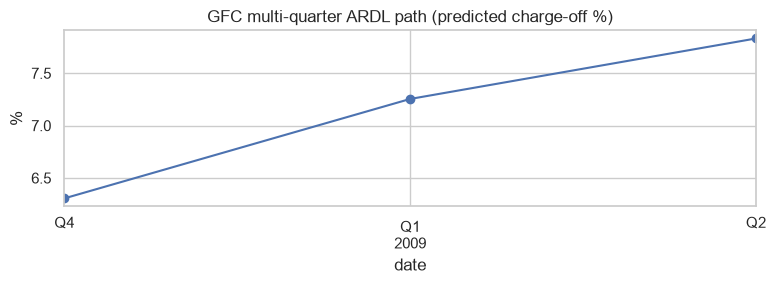

In [15]:
# --- helpers ---
def predict_from_state(model, own_lag: float, factors: dict) -> float:
    row = {f"{TARGET_COL}_L1": own_lag}
    for c in FACTOR_COLS:
        row[f"{c}_L1"] = factors[c]
    X = sm.add_constant(pd.DataFrame([row]), has_constant="add")
    X = X.reindex(columns=model.model.exog_names, fill_value=0.0)
    return float(model.predict(X).iloc[0])


def iterate_path(model, factor_path: pd.DataFrame, initial_own_lag: float) -> pd.DataFrame:
    own = initial_own_lag
    preds = []
    for dt, r in factor_path.iterrows():
        factors = {c: float(r[c]) for c in FACTOR_COLS}
        yhat = predict_from_state(model, own, factors)
        preds.append({"date": dt, "pred_charge_off": yhat, "own_lag_used": own})
        own = yhat
    return pd.DataFrame(preds).set_index("date")


HISTORICAL = {
    "GFC_peak": {
        "start": "2008-10-01",
        "end": "2009-06-30",
        "description": "Peak crisis quarters: unemployment and spreads elevated, GDP contracting.",
    },
    "COVID_shock": {
        "start": "2020-04-01",
        "end": "2020-09-30",
        "description": "Initial pandemic shock: unemployment spike, VIX surge, GDP collapse.",
    },
}

HYPOTHETICAL = [
    ("unemp_plus_3pp", {"unemployment": 3.0}, "+3pp unemployment"),
    ("spread_plus_200bp", {"credit_spread": 2.0}, "+200bp credit spread"),
    ("rate_plus_200bp", {"fed_funds": 2.0}, "+200bp fed funds"),
    ("vix_plus_20", {"vix": 20.0}, "+20 VIX points"),
    ("gdp_minus_4pp", {"gdp_yoy": -4.0}, "-4pp GDP YoY"),
    (
        "combined_adverse",
        {
            "unemployment": 3.0,
            "credit_spread": 2.0,
            "fed_funds": 1.0,
            "vix": 15.0,
            "gdp_yoy": -3.0,
        },
        "Multi-factor adverse pack",
    ),
]

latest_co = float(panel[TARGET_COL].dropna().iloc[-1])
base_factors = panel[FACTOR_COLS].dropna().iloc[-1]

rows = []

# baselines
rows.append({
    "scenario": "baseline_latest_actual",
    "type": "baseline",
    "description": "Latest observed charge-off rate",
    "charge_off_pct": latest_co,
})
rows.append({
    "scenario": "baseline_model_pred",
    "type": "baseline",
    "description": "ARDL at latest macros (own lag = latest actual)",
    "charge_off_pct": predict_from_state(model, latest_co, {c: float(base_factors[c]) for c in FACTOR_COLS}),
})

# historical one-step + path peak
for key, meta in HISTORICAL.items():
    window = panel.loc[meta["start"] : meta["end"], FACTOR_COLS]
    f_mean = window.mean()
    factors_mean = {c: float(f_mean[c]) for c in FACTOR_COLS}
    one_step = predict_from_state(model, latest_co, factors_mean)
    rows.append({
        "scenario": f"{key}_onestep",
        "type": "historical",
        "description": meta["description"] + " (one-step at window-mean factors)",
        "charge_off_pct": one_step,
    })

    pre = panel.loc[: meta["start"], TARGET_COL].dropna()
    init = float(pre.iloc[-2]) if len(pre) >= 2 else latest_co
    path = iterate_path(model, window, initial_own_lag=init)
    peak = float(path["pred_charge_off"].max())
    end_v = float(path["pred_charge_off"].iloc[-1])
    rows.append({
        "scenario": f"{key}_path_peak",
        "type": "historical",
        "description": meta["description"] + f" (path peak; end={end_v:.2f}%)",
        "charge_off_pct": peak,
    })
    # stash GFC path for chart
    if key == "GFC_peak":
        gfc_path = path

# hypotheticals
for name, shocks, desc in HYPOTHETICAL:
    f = base_factors.copy()
    for k, delta in shocks.items():
        f[k] = float(f[k]) + delta
    factors = {c: float(f[c]) for c in FACTOR_COLS}
    pred = predict_from_state(model, latest_co, factors)
    rows.append({
        "scenario": name,
        "type": "hypothetical",
        "description": desc,
        "charge_off_pct": pred,
    })

stress = pd.DataFrame(rows)
stress["delta_vs_latest_pp"] = stress["charge_off_pct"] - latest_co
display(stress[["scenario", "type", "charge_off_pct", "delta_vs_latest_pp"]].round(3))

# GFC path chart
fig, ax = plt.subplots(figsize=(8, 3))
gfc_path["pred_charge_off"].plot(ax=ax, marker="o")
ax.set_title("GFC multi-quarter ARDL path (predicted charge-off %)")
ax.set_ylabel("%")
fig.tight_layout()
plt.show()


**Interpretation — stress scenarios**

Stressed charge-offs sit **above** the latest actual — losses get worse under adverse macros, as expected. All figures below are model-implied on US aggregate FRED data and an **assumed** book size later; not a real bank portfolio.

**Baselines**
- Latest actual charge-off ≈ **3.82%** (book state entering stress).
- ARDL one-step at *today’s* macros ≈ **3.99%** (small positive bias vs actual; sanity check that the model is near current levels before shocking).

**Historical: one-step vs path peak**

| Scenario | One-step CO | Path peak CO | Δ vs latest (path) |
|----------|-------------|--------------|--------------------|
| GFC peak | ≈ 4.89% | ≈ **7.83%** | ≈ **+4.0 pp** |
| COVID shock | ≈ 4.63% | ≈ **5.30%** | ≈ **+1.5 pp** |

- **One-step** applies crisis window-mean macros once, with own lag = latest actual CO.
- **Path peak** walks the actual multi-quarter crisis macros and feeds each prediction back as the next own lag; the reported number is the **maximum** along that path.
- Path peaks are much larger than one-step because `charge_off_rate_L1 ≈ 0.91`: charge-offs are sticky, so crises **compound over several quarters**. One-shot stress understates multi-quarter crises.
- GFC path peak is the harsh historical case in this pack; COVID path is milder on this series.

**Hypothetical single-factor shocks (near today’s baseline)**

Ranked by how much predicted CO moves vs latest:

1. **GDP YoY −4 pp** → CO ≈ 4.62% (≈ +0.80 pp) — strongest single lever; matches the significant OLS GDP coefficient.
2. **Credit spread +200 bp** → ≈ 4.33% (≈ +0.51 pp) — right sign; useful sensitivity even if OLS p was weak.
3. **Fed funds +200 bp** → ≈ 4.12% (≈ +0.30 pp) — moderate rate channel.
4. **VIX +20** → ≈ 3.99% (≈ +0.17 pp) — weak after other factors (OLS coef ≈ 0).
5. **Unemployment +3 pp** → ≈ 3.78% (≈ −0.04 pp) — near-zero / wrong sign vs intuition; same weak identification as in OLS — do not oversell a clean UE story from this model.

**Combined adverse** (UE +3, spread +2, rates +1, VIX +15, GDP −3) → CO ≈ **4.64%** (≈ +0.82 pp). This is a designed multi-factor pack near *today’s* baseline (typically one-step). It does **not** have to beat the GFC path peak — different question (sensitivity design vs historical multi-quarter walk).

**Takeaway for seniors:** Use path peaks for “what if a crisis unfolds over time?”; use single-factor / combined hypotheticals for “which macro hurts most near current conditions?”


## 12. Expected Loss in Dollars

Assume an illustrative book: **$\text{EAD} = \$1{,}000{,}000{,}000$**.

$$
\text{EL} = \text{EAD} \times \frac{\text{CO}}{100}
$$

$$
\Delta\text{EL} = \text{EL}_{\text{stress}} - \text{EL}_{\text{latest}}
$$

Optional PV: $\text{PV}(\text{EL}) = \text{EL} \times 0.95$ — transparency only, **not** a calibrated funding curve.

In [16]:
EAD = 1_000_000_000
DISCOUNT = 0.95

def el_usd(co_pct: float, ead: float = EAD) -> float:
    return ead * (co_pct / 100.0)

stress = stress.copy()
stress["el_usd"] = stress["charge_off_pct"].map(el_usd)
stress["pv_el_usd"] = stress["el_usd"] * DISCOUNT
base_el = el_usd(latest_co)
stress["delta_el_usd"] = stress["el_usd"] - base_el
stress["delta_pv_el_usd"] = stress["pv_el_usd"] - base_el * DISCOUNT

display(
    stress[
        [
            "scenario",
            "type",
            "charge_off_pct",
            "delta_vs_latest_pp",
            "el_usd",
            "delta_el_usd",
            "delta_pv_el_usd",
        ]
    ].round(3)
)

print(f"Latest CO={latest_co:.2f}% → EL=${base_el/1e6:.1f}m on ${EAD/1e9:.0f}bn EAD")


,scenario,type,charge_off_pct,delta_vs_latest_pp,el_usd,delta_el_usd,delta_pv_el_usd
0,baseline_latest_actual,baseline,3.820,0.000,3.820000e+07,0.000000e+00,0.000000e+00
1,baseline_model_pred,baseline,3.993,0.173,3.992636e+07,1.726359e+06,1.640041e+06
2,GFC_peak_onestep,historical,4.893,1.073,4.893039e+07,1.073039e+07,1.019387e+07
3,GFC_peak_path_peak,historical,7.832,4.012,7.831788e+07,4.011788e+07,3.811199e+07
4,COVID_shock_onestep,historical,4.628,0.808,4.628470e+07,8.084704e+06,7.680469e+06
5,COVID_shock_path_peak,historical,5.300,1.480,5.300088e+07,1.480088e+07,1.406083e+07
6,unemp_plus_3pp,hypothetical,3.778,-0.042,3.778057e+07,-4.194308e+05,-3.984593e+05
7,spread_plus_200bp,hypothetical,4.325,0.505,4.325182e+07,5.051822e+06,4.799230e+06
8,rate_plus_200bp,hypothetical,4.115,0.295,4.115029e+07,2.950291e+06,2.802776e+06
9,vix_plus_20,hypothetical,3.992,0.172,3.991843e+07,1.718429e+06,1.632508e+06


Latest CO=3.82% → EL=$38.2m on $1bn EAD


### Expected loss interpretation (illustrative $1bn EAD)

Convert charge-off % into dollars:

EL = EAD × (CO / 100),   ΔEL = EL_stress − EL_latest

With latest actual CO = 3.82%:
- EL_latest ≈ $38.2m on $1bn EAD
- This is an **assumed** book size, not a real bank portfolio

**How much loss moves under stress (your run)**

| Scenario | CO % | Δ vs latest (pp) | EL ≈ | ΔEL ≈ |
|----------|------|------------------|------|-------|
| Latest actual | 3.82 | 0 | $38.2m | — |
| GFC one-step | 4.89 | +1.07 | $48.9m | +$10.7m |
| GFC path peak | 7.83 | +4.01 | $78.3m | +$40.1m |
| COVID one-step | 4.63 | +0.81 | $46.3m | +$8.1m |
| COVID path peak | 5.30 | +1.48 | $53.0m | +$14.8m |
| Combined adverse | 4.64 | +0.82 | $46.4m | +$8.2m |

- Path peaks >> one-step because own-lag ≈ 0.91: losses build over quarters.
- GFC path is the harsh historical case (~+$40m ΔEL).
- Combined adverse (~+$8m) is a designed shock near *today’s* baseline — it need not beat GFC.
- Optional PV (×0.95) is illustrative discounting only, not a calibrated curve.

## 13. Tornado sensitivity + executive summary

Single-factor hypotheticals only (exclude combined). Tallest bar = which shock moves $ EL most **in this model near today’s baseline**.


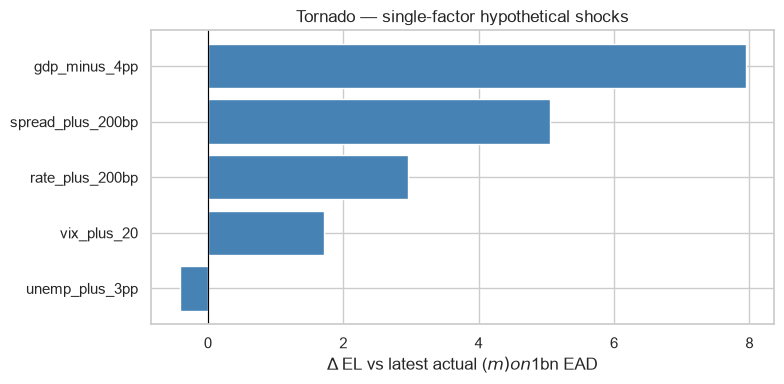

Executive summary
• Latest charge-off: 3.82%. Assumed EAD: $1,000,000,000.
• OOT MAE: ARDL 0.323 vs naive-last 0.730 (beats naive).
• GFC path peak 7.83% → ΔEL ≈ $40.1m.
• COVID path peak 5.30% → ΔEL ≈ $14.8m.
• Combined adverse 4.64% → ΔEL ≈ $8.2m (ΔPV-EL ≈ $7.8m).
• OLS is the governance / stress engine; GBM is challenger only. Not a CCAR / IPV model.


In [17]:
tornado = stress[
    (stress["type"] == "hypothetical") & (stress["scenario"] != "combined_adverse")
].copy()
tornado["abs_delta_el"] = tornado["delta_el_usd"].abs()
tornado = tornado.sort_values("abs_delta_el", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tornado["scenario"], tornado["delta_el_usd"] / 1e6, color="steelblue")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Δ EL vs latest actual ($m) on $1bn EAD")
ax.set_title("Tornado — single-factor hypothetical shocks")
fig.tight_layout()
plt.show()

# numbers for exec bullets
ols_mae = float(oot.loc[oot["model"] == "ARDL_OLS_primary", "MAE"].iloc[0])
naive_mae = float(oot.loc[oot["model"] == "naive_last", "MAE"].iloc[0])
gfc = stress.loc[stress["scenario"] == "GFC_peak_path_peak"].iloc[0]
covid = stress.loc[stress["scenario"] == "COVID_shock_path_peak"].iloc[0]
comb = stress.loc[stress["scenario"] == "combined_adverse"].iloc[0]

exec_lines = [
    f"Latest charge-off: {latest_co:.2f}%. Assumed EAD: ${EAD:,.0f}.",
    f"OOT MAE: ARDL {ols_mae:.3f} vs naive-last {naive_mae:.3f} (beats naive).",
    f"GFC path peak {gfc['charge_off_pct']:.2f}% → ΔEL ≈ ${gfc['delta_el_usd']/1e6:.1f}m.",
    f"COVID path peak {covid['charge_off_pct']:.2f}% → ΔEL ≈ ${covid['delta_el_usd']/1e6:.1f}m.",
    f"Combined adverse {comb['charge_off_pct']:.2f}% → ΔEL ≈ ${comb['delta_el_usd']/1e6:.1f}m (ΔPV-EL ≈ ${comb['delta_pv_el_usd']/1e6:.1f}m).",
    "OLS is the governance / stress engine; GBM is challenger only. Not a CCAR / IPV model.",
]
print("Executive summary")
for line in exec_lines:
    print("•", line)


### Tornado + which macros move charge-offs / EL

Tornado ranks **single-factor** hypotheticals by |ΔEL| near today’s baseline
(ceteris paribus in this linear ARDL — not a universal economic law).

**Ranking from your run (ΔCO vs latest 3.82%)**

| Shock | Design | Pred CO | ΔCO (pp) | ΔEL on $1bn |
|-------|--------|---------|----------|-------------|
| gdp_minus_4pp | GDP YoY −4 | 4.62% | +0.80 | ~+$8.0m |
| spread_plus_200bp | spread +2 | 4.33% | +0.51 | ~+$5.1m |
| rate_plus_200bp | fed funds +2 | 4.12% | +0.30 | ~+$3.0m |
| vix_plus_20 | VIX +20 | 3.99% | +0.17 | ~+$1.7m |
| unemp_plus_3pp | UE +3 | 3.78% | −0.04 | ~−$0.4m |

**What this says about “which macro matters”**
1. **GDP YoY** is the strongest single lever in this fit (matches significant OLS coef ≈ −0.16).
2. **Credit spread** is next; direction right even if OLS p was weak.
3. **Fed funds** moderate positive sensitivity.
4. **VIX** barely moves CO after other factors (OLS coef ≈ 0).
5. **Unemployment +3** slightly *lowers* predicted CO here — same wrong-sign / weak identification as in OLS; do not sell a clean UE story from this model.

**Combined adverse** (UE+3, spread+2, rates+1, VIX+15, GDP−3) → CO 4.64%, ΔEL ~+$8.2m:
multi-factor pack near today, smaller than GFC path peak because it is one-step from current CO, not a multi-quarter crisis walk.

**Exec read**
- Latest CO 3.82% → EL ~$38m on $1bn EAD.
- Worst historical path (GFC) → ~7.83%, ΔEL ~+$40m.
- Near-term sensitivity: GDP and spreads dominate the tornado; UE/VIX do not.

## 14. Limitations

- **US aggregate** charge-off / macro series ≠ your institution’s portfolio (mix, underwriting, forbearance).
- **Fixed EAD** — no drawdowns, attrition, or origination freeze under stress.
- **Linear ARDL** may miss nonlinear cliffs; GBM was only a challenger.
- **Ljung-Box lag-4** on residuals was significant (p≈0.025) — mild leftover dynamics; richer lags / ECM would be next.
- **Unemployment** coefficient had the wrong sign / was weak; do not over-claim that channel from this OLS alone.
- **FV bridge** (EL × 0.95) is illustrative — not IFRS 9 staging, AVA, or IPV vs independent prices.
